# RL-❗️QAS: <ins>R</ins>einforcement <ins>L</ins>earning for noisy <ins>Q</ins>uantum <ins>A</ins>rchitecture <ins>S</ins>earch

In the noiseless setting, the RL agent evaluates a candidate circuit by comparing its output state with the target Bell or GHZ state. In a realistic setting, gates and measurements are imperfect, so the circuit output is generally a **mixed state** rather than a pure state.

We model noise as a quantum channel $\mathcal{E}$ applied during circuit execution:

$$\rho_{\mathrm{out}} =
\mathcal{E}_{L}
\circ \mathcal{U}_{L}
\circ \cdots
\circ
\mathcal{E}_{1}
\circ \mathcal{U}_{1}
\left(\rho_{\mathrm{in}}\right),$$

where $\mathcal{U}_{\ell}$ is the ideal operation at step $\ell$, $\mathcal{E}_{\ell}$ is its associated noise channel, and $\rho$ is a density matrix.

The RL environment therefore becomes noise-aware: after an action appends a gate, the simulator applies both the intended gate and its noise channel. The reward can still be based on target-state fidelity, but it is now evaluated using the noisy output state:

$$
F(\rho_{\mathrm{out}}, \lvert \psi_{\mathrm{target}}\rangle)
=
\langle \psi_{\mathrm{target}} \rvert
\rho_{\mathrm{out}}
\lvert \psi_{\mathrm{target}}\rangle.
$$

A circuit is successful when it prepares a state that remains close to the target **despite accumulated noise**, rather than only under ideal simulation

## RL-QAS effected by the following noise types

<p align="center">
  <img src="RL-QAS_noise_type.png" alt="title">
</p>

## The framework is compromised!!

<p align="center">
  <img src="RL-QAS_noise.png" alt="title">
</p>

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity
import torch
import torch.nn as nn
import random
import copy
from collections import namedtuple
import numpy as np
from itertools import product

## Import dependencies for noise modelling

In [122]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, phase_damping_error

In [123]:
def dictionary_of_actions(num_qubits=3):
    """
    Restricted 3-qubit action space for the connectivity:

        q0 -- q1 -- q2

    CNOT action format:
        [control, target, num_qubits, 0]

    One-qubit action format:
        [num_qubits, 0, qubit, gate_id]

    gate_id:
        0 -> X
        1 -> Y
        2 -> Z
        3 -> H
    """

    if num_qubits != 3:
        raise ValueError("This restricted action dictionary is defined for 3 qubits.")

    action_dict = {}
    action_id = 0

    # Undirected physical couplings in the 3-qubit chain.
    coupling_edges = [
        (0, 1),
        (1, 2),
    ]

    # Add both directed CNOT choices for each allowed physical coupling.
    for q1, q2 in coupling_edges:
        action_dict[action_id] = [q1, q2, num_qubits, 0]
        action_id += 1

        action_dict[action_id] = [q2, q1, num_qubits, 0]
        action_id += 1

    # Add X, Y, Z, H on each individual qubit.
    for qubit, gate_id in product(range(num_qubits), range(4)):
        action_dict[action_id] = [num_qubits, 0, qubit, gate_id]
        action_id += 1

    return action_dict

## The action space looks same!

In [125]:
dictionary_of_actions(3)

{0: [0, 1, 3, 0],
 1: [1, 0, 3, 0],
 2: [1, 2, 3, 0],
 3: [2, 1, 3, 0],
 4: [3, 0, 0, 0],
 5: [3, 0, 0, 1],
 6: [3, 0, 0, 2],
 7: [3, 0, 0, 3],
 8: [3, 0, 1, 0],
 9: [3, 0, 1, 1],
 10: [3, 0, 1, 2],
 11: [3, 0, 1, 3],
 12: [3, 0, 2, 0],
 13: [3, 0, 2, 1],
 14: [3, 0, 2, 2],
 15: [3, 0, 2, 3]}

In [126]:
class RLQAS_Env:
    """
    RL-QAS environment for:
      - Bell state, 2 qubits: (|00> + |11>) / sqrt(2)
      - GHZ state,  3 qubits: (|000> + |111>) / sqrt(2)

    Noise models:
      "none"           : Ideal statevector simulation.
      "depolarizing"   : Depolarizing noise after each gate.
      "dephasing"      : Phase damping after each gate.
      "combined"       : Depolarizing followed by phase damping after each gate.

    Parameters:
      p_dep_1q   : Depolarizing strength after X, Y, Z, H.
      p_dep_2q   : Depolarizing strength after CX.
      p_deph_1q  : Phase-damping strength after X, Y, Z, H.
      p_deph_2q  : Phase-damping strength per qubit after CX.
    """

    def __init__(
        self,
        num_qubits=2,
        num_layers=4,
        fidelity_reward_scale=50.0,
        done_threshold=0.99,
        noise_model="none",
        p_dep_1q=0.001,
        p_dep_2q=0.01,
        p_deph_1q=0.001,
        p_deph_2q=0.01,
        device="cpu",
    ):

        if num_qubits not in [2, 3]:
            raise ValueError(
                "This example supports only 2-qubit Bell and 3-qubit GHZ targets."
            )

        valid_noise_models = {
            "none",
            "depolarizing",
            "dephasing",
            "combined",
        }

        if noise_model not in valid_noise_models:
            raise ValueError(
                f"noise_model must be one of {valid_noise_models}; "
                f"received '{noise_model}'."
            )

        self.num_qubits = num_qubits
        self.num_layers = num_layers
        self.device = torch.device(device)

        self.fidelity_reward_scale = fidelity_reward_scale
        self.done_threshold = done_threshold

        self.noise_model_name = noise_model
        self.p_dep_1q = p_dep_1q
        self.p_dep_2q = p_dep_2q
        self.p_deph_1q = p_deph_1q
        self.p_deph_2q = p_deph_2q

        self.state_size = (
            self.num_layers
            * self.num_qubits
            * (self.num_qubits + 4)
        )

        self.action_size = self.num_qubits * (self.num_qubits + 4)

        if self.num_qubits == 2:
            target_vector = np.array(
                [1, 0, 0, 1],
                dtype=complex,
            ) / np.sqrt(2)

        else:
            target_vector = np.array(
                [1, 0, 0, 0, 0, 0, 0, 1],
                dtype=complex,
            ) / np.sqrt(2)

        self.target_statevector = Statevector(target_vector)

        self.target_density_matrix = DensityMatrix(
            np.outer(target_vector, target_vector.conj())
        )

        self.aer_noise_model = self._build_noise_model()

        # Ideal case: use the statevector simulator.
        if self.noise_model_name == "none":
            self.sim = AerSimulator(method="statevector")

        # Noisy cases: use a density matrix because noise yields mixed states.
        else:
            self.sim = AerSimulator(
                method="density_matrix",
                noise_model=self.aer_noise_model,
            )

        self.state = None
        self.moments = None
        self.step_counter = None
        self.error = None
        self.prev_cost = None

    def _build_noise_model(self):
        """Create the requested gate-noise model."""

        if self.noise_model_name == "none":
            return None

        noise = NoiseModel()

        depol_1q = depolarizing_error(self.p_dep_1q, 1)
        depol_2q = depolarizing_error(self.p_dep_2q, 2)

        dephase_1q = phase_damping_error(self.p_deph_1q)

        # Independent phase damping on the two qubits involved in CX.
        dephase_2q = dephase_1q.tensor(dephase_1q)

        one_qubit_gates = ["x", "y", "z", "h"]
        two_qubit_gates = ["cx"]

        if self.noise_model_name == "depolarizing":
            noise.add_all_qubit_quantum_error(
                depol_1q,
                one_qubit_gates,
            )

            noise.add_all_qubit_quantum_error(
                depol_2q,
                two_qubit_gates,
            )

        elif self.noise_model_name == "dephasing":
            noise.add_all_qubit_quantum_error(
                dephase_1q,
                one_qubit_gates,
            )

            noise.add_all_qubit_quantum_error(
                dephase_2q,
                two_qubit_gates,
            )

        elif self.noise_model_name == "combined":
            combined_1q = depol_1q.compose(dephase_1q)
            combined_2q = depol_2q.compose(dephase_2q)

            noise.add_all_qubit_quantum_error(
                combined_1q,
                one_qubit_gates,
            )

            noise.add_all_qubit_quantum_error(
                combined_2q,
                two_qubit_gates,
            )

        return noise

    def reset(self):
        """Reset circuit state and return the flattened RL representation."""

        self.state = torch.zeros(
            (
                self.num_layers,
                self.num_qubits + 4,
                self.num_qubits,
            ),
            dtype=torch.float32,
        )

        self.moments = [0] * self.num_qubits
        self.step_counter = -1

        self.prev_cost = self._compute_fidelity()

        # Kept to match your original convention:
        # self.error actually stores fidelity.
        self.error = float(self.prev_cost)

        return self.state.reshape(-1).to(self.device)

    def step(self, action, train_flag=True):
        """
        action = [ctrl, targ, rot_qubit, rot_axis]

        rot_axis:
          0 -> X
          1 -> Y
          2 -> Z
          3 -> H
        """

        if isinstance(action, torch.Tensor):
            action = action.detach().cpu().tolist()

        ctrl = int(action[0])
        targ = int(action[1])
        rot_qubit = int(action[2])
        rot_axis = int(action[3])

        next_state = self.state.clone()
        self.step_counter += 1

        valid_cnot = (
            ctrl < self.num_qubits
            and targ < self.num_qubits
            and ctrl != targ
        )

        valid_oneq = (
            rot_qubit < self.num_qubits
            and 0 <= rot_axis < 4
        )

        if valid_oneq:
            gate_layer = self.moments[rot_qubit]

        elif valid_cnot:
            gate_layer = max(
                self.moments[ctrl],
                self.moments[targ],
            )

        else:
            gate_layer = 0

        if gate_layer >= self.num_layers:
            fidelity = self._compute_fidelity()

            self.prev_cost = fidelity
            self.error = float(fidelity)

            return (
                self.state.reshape(-1).to(self.device),
                torch.tensor(
                    0.0,
                    dtype=torch.float32,
                    device=self.device,
                ),
                True,
            )

        if valid_cnot:
            next_state[gate_layer, targ, ctrl] = 1.0

        if valid_oneq:
            oneq_row = self.num_qubits + rot_axis
            next_state[gate_layer, oneq_row, rot_qubit] = 1.0

        if valid_oneq:
            self.moments[rot_qubit] += 1

        elif valid_cnot:
            next_moment = max(
                self.moments[ctrl],
                self.moments[targ],
            ) + 1

            self.moments[ctrl] = next_moment
            self.moments[targ] = next_moment

        self.state = next_state

        fidelity = self._compute_fidelity()

        # Kept identical in meaning to your original code:
        # error stores fidelity.
        self.error = float(fidelity)

        reward = self._reward_from_fidelity(fidelity)
        self.prev_cost = fidelity

        done_success = fidelity >= self.done_threshold
        done_layers = self.step_counter >= self.num_layers - 1

        done = bool(done_success or done_layers)

        return (
            self.state.reshape(-1).to(self.device),
            torch.tensor(
                reward,
                dtype=torch.float32,
                device=self.device,
            ),
            done,
        )

    def _make_circuit(self):
        """Convert the RL tensor encoding into a QuantumCircuit."""

        circ = QuantumCircuit(self.num_qubits)

        state_np = self.state.detach().cpu().numpy()

        for layer in range(self.num_layers):

            cnot_block = state_np[
                layer,
                :self.num_qubits,
                :,
            ]

            targ_indices, ctrl_indices = np.where(cnot_block == 1.0)

            for targ, ctrl in zip(targ_indices, ctrl_indices):
                if ctrl != targ:
                    circ.cx(int(ctrl), int(targ))

            oneq_block = state_np[
                layer,
                self.num_qubits:self.num_qubits + 4,
                :,
            ]

            gate_rows, qubits = np.where(oneq_block == 1.0)

            for gate_row, qubit in zip(gate_rows, qubits):

                if gate_row == 0:
                    circ.x(int(qubit))

                elif gate_row == 1:
                    circ.y(int(qubit))

                elif gate_row == 2:
                    circ.z(int(qubit))

                elif gate_row == 3:
                    circ.h(int(qubit))

        return circ

    def _compute_fidelity(self):
        """
        Evaluate final target fidelity.

        Ideal case:
          statevector simulator + save_statevector.

        Noisy case:
          density-matrix simulator + save_density_matrix.
        """

        circ = self._make_circuit()

        if self.noise_model_name == "none":
            circ.save_statevector(label="final_state")

            result = self.sim.run(circ).result()

            evolved_state = Statevector(
                result.data(0)["final_state"]
            )

            fidelity = state_fidelity(
                evolved_state,
                self.target_statevector,
            )

        else:
            circ.save_density_matrix(label="final_state")

            result = self.sim.run(circ).result()

            evolved_state = DensityMatrix(
                result.data(0)["final_state"]
            )

            fidelity = state_fidelity(
                evolved_state,
                self.target_density_matrix,
            )

        return float(fidelity)

    def _reward_from_fidelity(self, x=None):
        """
        Original reward behavior retained:
        self.error stores fidelity.
        """

        scalar = 50

        if self.error >= self.done_threshold:
            rwd = scalar * self.error

        else:
            rwd = self.error

        return rwd

In [127]:
num_qubits, max_steps, num_episodes = 3, 8, 5000

"""
IDEAL
"""
env_noiseless = RLQAS_Env(num_qubits=num_qubits, num_layers=max_steps, noise_model="none",)

"""
Depolarizing
"""
env_depolarizing = RLQAS_Env(
    num_qubits=num_qubits,
    num_layers=max_steps,
    noise_model="depolarizing",
    p_dep_1q=0.001,
    p_dep_2q=0.01,
)

"""
Dephasing
"""
env_dephasing = RLQAS_Env(
    num_qubits=2,
    num_layers=4,
    noise_model="dephasing",
    p_deph_1q=0.002,
    p_deph_2q=0.01,
)

"""
Deplorizing & dephasing
"""
env_noise_combined = RLQAS_Env(
    num_qubits=2,
    num_layers=6,
    noise_model="combined",
    p_dep_1q=0.001,
    p_dep_2q=0.01,
    p_deph_1q=0.002,
    p_deph_2q=0.001,
    done_threshold=0.95,
)


## Random search

In [128]:
environment_type_list = ["none", "deplorizing", "dephasing", "combined"]

environment_type = environment_type_list[0]

if environment_type == environment_type_list[0]:
    env = env_noiseless
    comment = "😇 Noiseless Mode Activated 😇"
elif environment_type == environment_type_list[1]:
    env = env_depolarizing
    comment = "😬 Depolarizing Noise Activated! Need to work harder! 😬"
elif environment_type == environment_type_list[2]:
    env = env_dephasing
    comment = "😬 Dephasing Noise Activated! Need to work harder! 😬"
elif environment_type == environment_type_list[3]:
    env = env_noise_combined
    comment = "😤 Both Noise Models Are Activated! Need to work much harder! 😤"

actions_dict = dictionary_of_actions(num_qubits)
num_actions = len(actions_dict)
random_search_fidelities = []

print('--------------------------')
print(comment)
print("RANDOM SEARHCING!")
print('--------------------------')
print()

for ep in range(num_episodes):
    # print(f"\n=== Episode {ep+1} ===")
    state = env.reset()
    # print("Initial fidelity:", env.prev_cost)

    for step in range(max_steps):
        # sample a random action index
        a_idx = random.randint(0, num_actions - 1)
        action = actions_dict[a_idx]

        # step in the environment
        next_state, reward, done = env.step(action)

        if done:
            # done should correspond to fidelity reaching 1 (or your threshold)
            break
    # print(f"  Episode {ep}: fidelity={env.prev_cost:.6f}, reward={reward.item():.4f}, done={done}")
    if ep % 10 == 0:
        print("Episode:", ep, "finished after", step+1, "steps.", "Final fidelity:", env.prev_cost)
    random_search_fidelities.append(env.prev_cost)

--------------------------
😇 Noiseless Mode Activated 😇
RANDOM SEARHCING!
--------------------------

Episode: 0 finished after 8 steps. Final fidelity: 0.2500000000000001
Episode: 10 finished after 8 steps. Final fidelity: 0.12500000000000003
Episode: 20 finished after 8 steps. Final fidelity: 0.25
Episode: 30 finished after 8 steps. Final fidelity: 0.25
Episode: 40 finished after 8 steps. Final fidelity: 2.784817386906511e-33
Episode: 50 finished after 8 steps. Final fidelity: 1.2016997346404043e-33
Episode: 60 finished after 8 steps. Final fidelity: 0.0
Episode: 70 finished after 8 steps. Final fidelity: 0.0
Episode: 80 finished after 8 steps. Final fidelity: 0.25
Episode: 90 finished after 8 steps. Final fidelity: 0.25
Episode: 100 finished after 8 steps. Final fidelity: 2.784817386906511e-33
Episode: 110 finished after 8 steps. Final fidelity: 0.25
Episode: 120 finished after 8 steps. Final fidelity: 0.0
Episode: 130 finished after 8 steps. Final fidelity: 0.0
Episode: 140 finishe

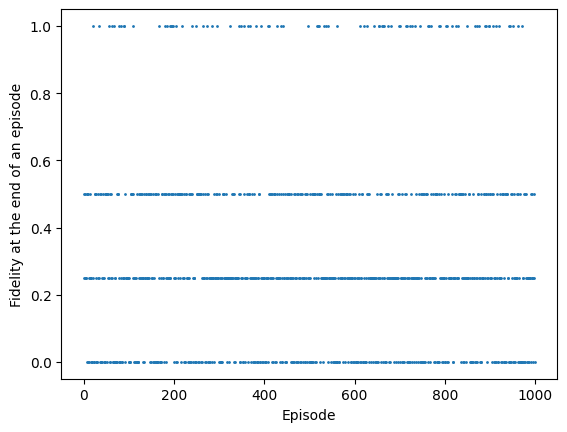

In [129]:
import matplotlib.pyplot as plt
plt.plot(fidelities, 'o', markersize = 1)
plt.ylabel('Fidelity at the end of an episode')
plt.xlabel('Episode')
plt.show()

## Training the agent

In [130]:
num_qubits, max_steps, num_episodes = 3, 8, 5000

import torch.optim as optim

num_actions = len(actions_dict)
device = torch.device("cpu")


print('--------------------------')
if environment_type == environment_type_list[0]:
    env = env_noiseless
    comment = "😇 Noiseless Mode Activated 😇"
elif environment_type == environment_type_list[1]:
    env = env_depolarizing
    comment = "😬 Depolarizing Noise Activated! Need to work harder! 😬"
elif environment_type == environment_type_list[2]:
    env = env_dephasing
    comment = "😬 Dephasing Noise Activated! Need to work harder! 😬"
elif environment_type == environment_type_list[3]:
    env = env_noise_combined
    comment = "😤 Both Noise Models Are Activated! Need to work much harder! 😤"
print(comment)
print("SEARCHIGN WITH JUST ONE LAYER NEURAL NETWORK UNDER RL-FRAMEWORK!")
print('--------------------------')
print()

state_dim = env.state_size  # flattened state length
action_dim = num_actions    # discrete actions 0..9

# --- tiny DQN network ---
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

q_net = DQN(state_dim, action_dim).to(device)
target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=3e-4)
loss_fn = nn.MSELoss()

# --- simple replay buffer ---
replay_buffer = []
buffer_capacity = 10000
batch_size = 64
gamma = 0.99

def push_transition(transition):
    if len(replay_buffer) >= buffer_capacity:
        replay_buffer.pop(0)
    replay_buffer.append(transition)

def sample_batch():
    batch = random.sample(replay_buffer, batch_size)
    state_b, action_b, reward_b, next_state_b, done_b = zip(*batch)
    state_b = torch.stack(state_b)
    action_b = torch.tensor(action_b, dtype=torch.long, device=device)
    reward_b = torch.tensor(reward_b, dtype=torch.float32, device=device)
    next_state_b = torch.stack(next_state_b)
    done_b = torch.tensor(done_b, dtype=torch.float32, device=device)
    return state_b, action_b, reward_b, next_state_b, done_b

# --- epsilon-greedy parameters ---
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 10000   # in steps
global_step = 0

def get_epsilon(step):
    return max(epsilon_end, epsilon_start - step / epsilon_decay)

def select_action(state_vec):
    global global_step
    epsilon = get_epsilon(global_step)
    global_step += 1
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    with torch.no_grad():
        q_values = q_net(state_vec.unsqueeze(0))
        return int(q_values.argmax(dim=1).item())

# --- training loop ---
max_steps_per_episode = max_steps
target_update_freq = 100  # episodes

episode_rewards = []
episode_final_fidelities = []
episode_final_epsilons = []
episode_num_gates = []  # total gates used in that episode

for ep in range(num_episodes):
    state = env.reset()                         # shape: [state_dim], already on device
    state = state.to(device)
    total_reward = 0.0
    total_gates = 0

    for t in range(max_steps_per_episode):
        # choose action index via epsilon-greedy
        a_idx = select_action(state)
        action = actions_dict[a_idx]

        # step environment
        next_state, reward_t, done = env.step(action)
        next_state = next_state.to(device)

        r = reward_t.item()
        total_reward += r

        # count how many gates are present in the circuit state after this step
        # (you can also use env.moments if you prefer; here we just count nonzeros)
        total_gates = int((env.state.numpy() != 0).sum())

        # store transition in replay buffer
        push_transition((
            state,
            a_idx,
            r,
            next_state,
            float(done)
        ))

        state = next_state

        # DQN update
        if len(replay_buffer) >= batch_size:
            s_b, a_b, r_b, ns_b, d_b = sample_batch()

            # current Q(s, a)
            q_values = q_net(s_b)
            q_sa = q_values.gather(1, a_b.unsqueeze(1)).squeeze(1)

            # target Q = r + gamma * max_a' Q_target(s', a') * (1 - done)
            with torch.no_grad():
                next_q_values = target_net(ns_b)
                max_next_q = next_q_values.max(dim=1)[0]
                target_q = r_b + gamma * max_next_q * (1.0 - d_b)

            loss = loss_fn(q_sa, target_q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break #requires applicants to provide a

    # episode-level logging
    episode_rewards.append(total_reward)
    episode_final_fidelities.append(env.prev_cost)
    episode_num_gates.append(total_gates)
    episode_final_epsilons.append(get_epsilon(global_step))

    # update target network
    if (ep + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    if (ep + 1) % 10 == 0:
        print(f"Episode {ep+1:3d} | total reward = {total_reward:.3f} | "
              f"last fidelity = {env.prev_cost:.6f} | gates = {total_gates} | "
              f"epsilon = {episode_final_epsilons[-1]:.3f}")

print("Training finished.")

# quick greedy evaluation run
state = env.reset().to(device)
for t in range(max_steps_per_episode):
    with torch.no_grad():
        q_vals = q_net(state.unsqueeze(0))
        a_idx = int(q_vals.argmax(dim=1).item())
    action = actions_dict[a_idx]
    next_state, reward_t, done = env.step(action)
    state = next_state.to(device)
    print(f"Eval step {t+1}: action_id={a_idx}, action={action}, fidelity={env.prev_cost:.6f}, reward={reward_t.item():.3f}, done={done}")
    if done:
        break

# Now you can plot episode_rewards, episode_final_fidelities,
# episode_final_epsilons, episode_num_gates after training.

--------------------------
😇 Noiseless Mode Activated 😇
SEARCHIGN WITH JUST ONE LAYER NEURAL NETWORK UNDER RL-FRAMEWORK!
--------------------------

Episode  10 | total reward = 1.500 | last fidelity = 0.250000 | gates = 8 | epsilon = 0.992
Episode  20 | total reward = 0.000 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.984
Episode  30 | total reward = 1.000 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.976
Episode  40 | total reward = 2.500 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.968
Episode  50 | total reward = 0.500 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.960
Episode  60 | total reward = 2.000 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.952
Episode  70 | total reward = 1.750 | last fidelity = 0.250000 | gates = 8 | epsilon = 0.944
Episode  80 | total reward = 1.500 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.936
Episode  90 | total reward = 1.500 | last fidelity = 0.000000 | gates = 8 | epsilon = 0.928
Episode 100 | total rew

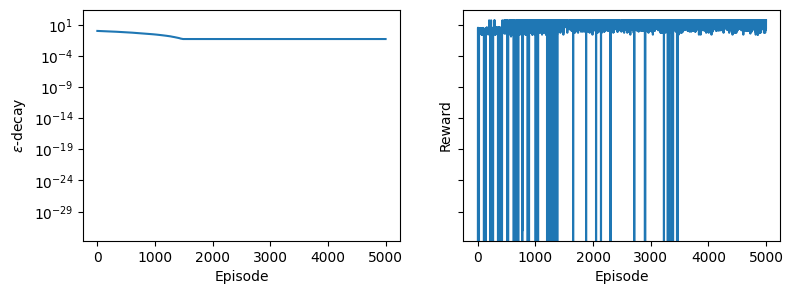

In [131]:
fig, ax = plt.subplots(1, 2, figsize = (9, 3), sharey = True)

ax[0].semilogy(episode_final_epsilons)
ax[0].set_ylabel('$\\epsilon$-decay')
ax[1].semilogy(episode_rewards)
ax[1].set_ylabel('Reward')
ax[0].set_xlabel('Episode')
ax[1].set_xlabel('Episode')
plt.show()

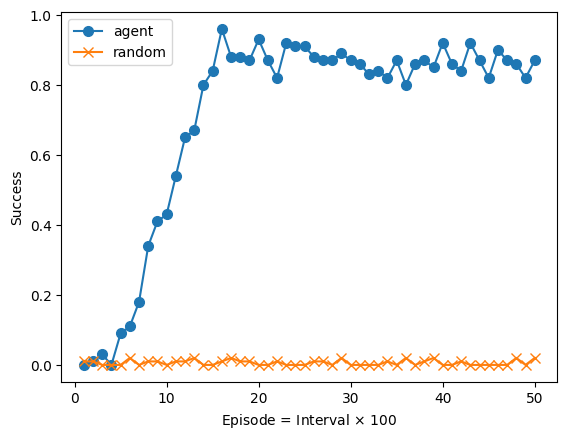

In [132]:
# fig, ax = plt.subplots(1, 2, figsize = (9, 3))

chunk_size = 100
threshold = 0.95  # or env.done_threshold if you prefer >= threshold as success

num_chunks = (num_episodes + chunk_size - 1) // chunk_size  # ceil

chunk_success_rates_agent = []
chunk_success_rates_random = []

for k in range(num_chunks):
    start = k * chunk_size
    end = min((k + 1) * chunk_size, num_episodes)

    # slice the fidelities for this chunk
    fidelities_chunk_agent = episode_final_fidelities[start:end]
    fidelities_chunk_random = random_search_fidelities[start:end]

    # count successes (agent)
    successes = sum(1 for f in fidelities_chunk_agent if f >= threshold)
    length = len(fidelities_chunk_agent)
    success_rate = successes / length if length > 0 else 0.0
    chunk_success_rates_agent.append(success_rate)

    # count successes (random)
    successes = sum(1 for f in fidelities_chunk_random if f >= threshold)
    length = len(fidelities_chunk_agent)
    success_rate = successes / length if length > 0 else 0.0
    chunk_success_rates_random.append(success_rate)
    

plt.plot(range(1, len(chunk_success_rates_agent)+1), chunk_success_rates_agent, '-o', markersize = 7, label = 'agent')
plt.plot(range(1, len(chunk_success_rates_random)+1), chunk_success_rates_random, '-x', markersize = 7, label = 'random')
plt.xlabel('Episode = Interval $\\times$ 100')
plt.ylabel('Success')
plt.legend()
plt.show()